# Evaluación 2 — Programación Científica 2026-1
### Redes que aprenden bases: ¿ayuda arrancar en Fourier?

**Estudiante:** Juan Felipe Muriel Mosquera &nbsp;&nbsp;·&nbsp;&nbsp; **ID:** 102040**6050** &nbsp;&nbsp;·&nbsp;&nbsp; **Curso:** Programación Científica

Este notebook resuelve la Evaluación 2 siguiendo `enunciado_6050.md`. Parámetros personalizados de este ID:

| Parámetro | Valor |
|---|---|
| Frecuencias de la capa Fourier ($K$) | 25 |
| Señales por régimen | 15 (45 en total) |
| Iteraciones de entrenamiento | 3000 |
| Learning rate ($\eta$) | 0.02 |
| Régimen foco | 1 (dispersión intermedia) |
| Umbral de compresión | 95% de la energía |


In [1]:
!sudo apt-get update
!sudo apt-get install -y texlive-latex-recommended texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [2]:
#Importe de paquetes necesarios.

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random

#Setup estético para la visualización.

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage[utf8]{inputenc} \usepackage[T1]{fontenc} \usepackage{amsmath}",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})
COLOR_REGIMEN = {0: "tab:blue", 1: "tab:green", 2: "tab:red"}
COLOR_INIT    = {"fourier": "tab:purple", "aleatoria": "tab:orange"}

print("Configuración LaTeX OK")

Configuración LaTeX OK


In [3]:
# --- parámetros del enunciado personalizado (ID 6050) ---
K        = 25
N        = 256
N_ITER   = 3000
ETA      = 0.02
FOCO     = 1
ENERGIA  = 0.95
SEED     = 6050
key      = random.PRNGKey(SEED)

## Carga de datos

Cargamos `datos_6050.npz`, generado con `generar_datos.py 6050`. Contiene 45 señales (15 por régimen), cada una de 256 muestras.

In [4]:
d = np.load("datos_6050.npz", allow_pickle=True)
X, y, t = d["X"], d["y"], d["t"]

print(f"X: {X.shape}  (n_señales, n_muestras)")
print(f"y: {y.shape}  regímenes presentes: {sorted(set(y.tolist()))}, conteo: "
      f"{[int((y==r).sum()) for r in [0,1,2]]}")
print(f"t: {t.shape}  rango [{t.min():.3f}, {t.max():.3f}]")


X: (45, 256)  (n_señales, n_muestras)
y: (45,)  regímenes presentes: [0, 1, 2], conteo: [15, 15, 15]
t: (256,)  rango [0.000, 0.996]


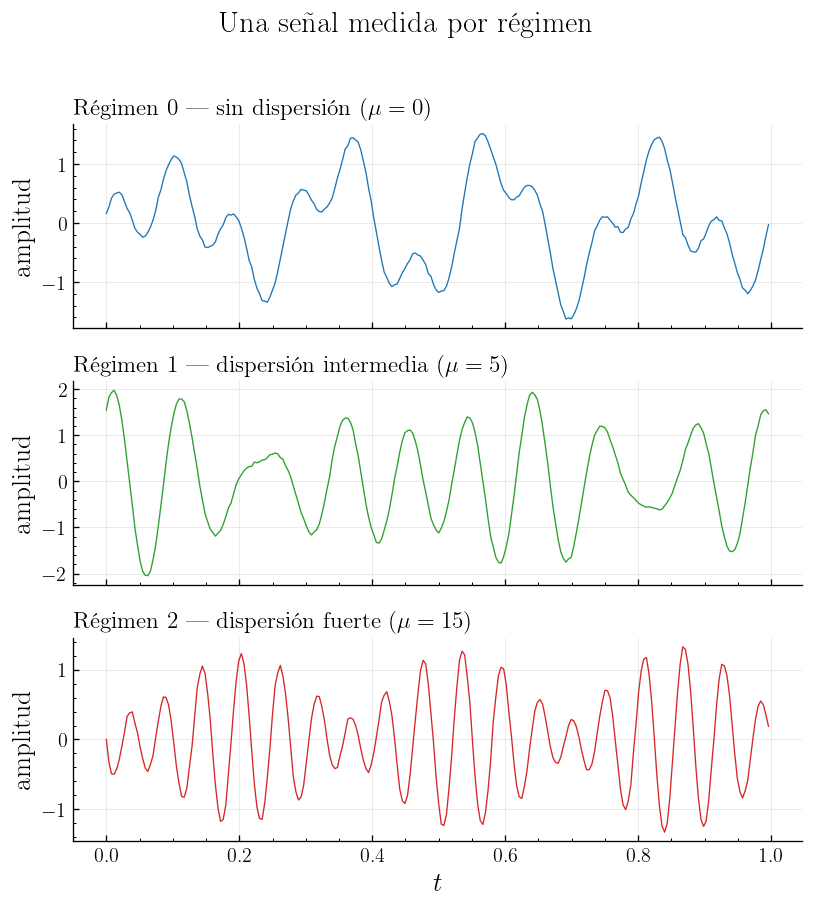

In [5]:
# ── Gráfica: una señal de ejemplo por régimen (estilo LaTeX) ──
titulos = {
    0: r"Régimen 0 --- sin dispersión ($\mu=0$)",
    1: r"Régimen 1 --- dispersión intermedia ($\mu=5$)",
    2: r"Régimen 2 --- dispersión fuerte ($\mu=15$)",
}

fig, axes = plt.subplots(3, 1, figsize=(7, 7.5), sharex=True)
for r, ax in zip([0, 1, 2], axes):
    x_ejemplo = X[y == r][0]
    ax.plot(t, x_ejemplo, color=COLOR_REGIMEN[r], lw=0.8)
    ax.set_title(titulos[r], fontsize=14, loc="left")
    ax.set_ylabel(r"amplitud")
    ax.grid(True, color="lightgray", linestyle="-", linewidth=0.4, alpha=0.7, zorder=0)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(r"Una señal medida por régimen", y=1.01, fontsize=18)
fig.tight_layout()
plt.savefig("fig_senales_por_regimen.pdf")
plt.show()


## La capa Fourier

$W_1$ tiene $2K$ filas: las primeras $K$ son $\sin(2\pi k t)$ y las siguientes $K$ son $\cos(2\pi k t)$, para $k=1,\dots,K$.
Al multiplicar $W_1 x$ (antes de $\tanh$), cada fila calcula la proyección de $x$ sobre un seno o coseno de frecuencia $k$
— eso es, por definición, una transformada de Fourier en su versión seno/coseno (parte real/imaginaria de la DFT).

In [6]:
def build_fourier_layer(K, t):
    """Construye W1 (2K, len(t)): filas sin(2*pi*k*t) seguidas de cos(2*pi*k*t), k=1..K."""
    ks = jnp.arange(1, K + 1)
    S = jnp.sin(2 * jnp.pi * jnp.outer(ks, t))
    C = jnp.cos(2 * jnp.pi * jnp.outer(ks, t))
    return jnp.concatenate([S, C], axis=0)

W1_fourier = build_fourier_layer(K, jnp.array(t))
print("W1_fourier:", W1_fourier.shape)


W1_fourier: (50, 256)


**Verificación contra `np.fft`.** `np.fft.rfft` recibe **una** señal 1-D (256 muestras reales) y devuelve un vector
complejo con las componentes de frecuencia $k=0,\dots,128$: la parte real es la proyección sobre cosenos, la parte
imaginaria (con signo opuesto) es la proyección sobre senos. Actúa señal por señal — para el dataset completo hay que
aplicarlo fila por fila de `X` (o con `axis=1`, que internamente sigue siendo "una FFT por señal"). Comparamos, para
una señal, las proyecciones manuales de $W_1$ contra `np.fft.rfft`:

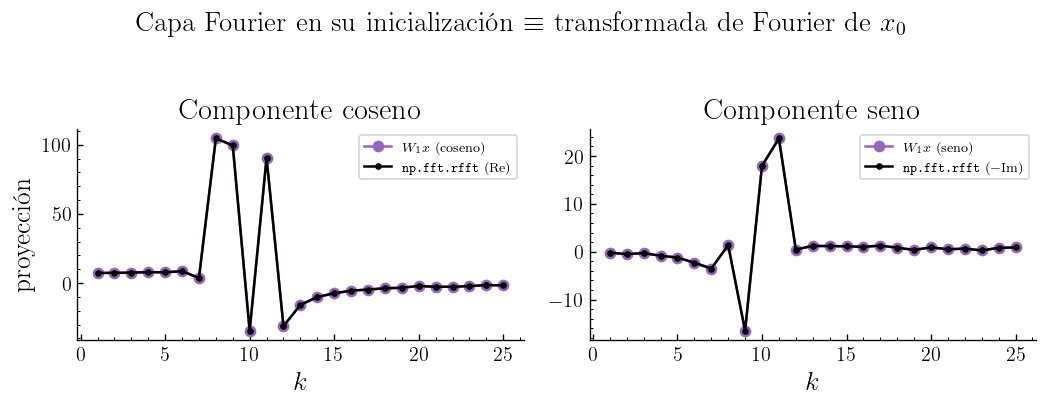

Discrepancia máxima W1 vs np.fft: 1.57e-04  (debe ser ~0)
Energía media del dataset (X**2).mean() = 0.742


In [7]:
x0 = X[0]
proyeccion = W1_fourier @ jnp.array(x0)
fft_np = np.fft.rfft(x0)

ks = np.arange(1, K + 1)
cos_manual = np.array(proyeccion[K:])
sin_manual = np.array(proyeccion[:K])
cos_fft = fft_np[1:K+1].real
sin_fft = -fft_np[1:K+1].imag

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
axes[0].plot(ks, cos_manual, "o-", color="tab:purple", label=r"$W_1 x$ (coseno)")
axes[0].plot(ks, cos_fft, ".-", color="k", label=r"\texttt{np.fft.rfft} (Re)")
axes[0].set_xlabel(r"$k$"); axes[0].set_ylabel(r"proyección")
axes[0].set_title(r"Componente coseno"); axes[0].legend(fontsize=8)

axes[1].plot(ks, sin_manual, "o-", color="tab:purple", label=r"$W_1 x$ (seno)")
axes[1].plot(ks, sin_fft, ".-", color="k", label=r"\texttt{np.fft.rfft} ($-$Im)")
axes[1].set_xlabel(r"$k$")
axes[1].set_title(r"Componente seno"); axes[1].legend(fontsize=8)

fig.suptitle(r"Capa Fourier en su inicialización $\equiv$ transformada de Fourier de $x_0$", y=1.03)
fig.tight_layout()
plt.show()

error_max = np.max(np.abs(cos_manual - cos_fft)) + np.max(np.abs(sin_manual - sin_fft))
print(f"Discrepancia máxima W1 vs np.fft: {error_max:.2e}  (debe ser ~0)")

energia_media = float((X**2).mean())
print(f"Energía media del dataset (X**2).mean() = {energia_media:.3f}")


## La red en JAX

$$\hat x = W_2\,\tanh(W_1 x), \qquad \mathcal{L}=\tfrac1N\|\hat x-x\|^2$$

Para que la comparación entre inicializaciones sea **justa**, la matriz aleatoria se genera con la misma escala típica
por entrada que la matriz de Fourier ($\mathbb{E}[w^2]=0.5$, igual que un seno o coseno promedio) — así la diferencia
de resultados se debe a la *estructura* de $W_1$, no simplemente a que una parta con números más grandes que la otra.

In [8]:
def init_fourier(K, t):
    return build_fourier_layer(K, t)

def init_random(K, N_dim, key):
    # misma varianza por entrada que sin/cos: E[w^2] = 0.5
    return random.normal(key, (2 * K, N_dim)) * jnp.sqrt(0.5)

def init_W2(K, N_dim, key):
    return random.normal(key, (N_dim, 2 * K)) / jnp.sqrt(2 * K)

def forward(params, x):
    W1, W2 = params
    h = jnp.tanh(W1 @ x)
    return W2 @ h

forward_batch = vmap(forward, in_axes=(None, 0))

def loss_fn(params, Xb):
    Xhat = forward_batch(params, Xb)
    return jnp.mean((Xhat - Xb) ** 2)

@jit
def train_step(params, Xb, eta):
    W1, W2 = params
    g_W1, g_W2 = grad(loss_fn)(params, Xb)
    return (W1 - eta * g_W1, W2 - eta * g_W2)

def error_relativo(params, Xb):
    Xhat = forward_batch(params, Xb)
    return float(jnp.linalg.norm(Xhat - Xb) / jnp.linalg.norm(Xb))

def entrenar(params0, Xb, n_iter, eta):
    params = params0
    losses = np.zeros(n_iter)
    rel_errs = np.zeros(n_iter)
    for i in range(n_iter):
        losses[i] = float(loss_fn(params, Xb))
        rel_errs[i] = error_relativo(params, Xb)
        params = train_step(params, Xb, eta)
    return params, losses, rel_errs


**Separación entrenamiento / validación.** Con 15 señales por régimen usamos 12 para entrenar y **3 como
validación** (nunca vistas durante el entrenamiento). El error de reconstrucción que se reporta como resultado debe
venir de la validación — el de entrenamiento siempre es optimista. Entrenamos, **por régimen**, dos redes (una por
inicialización), para aislar el efecto de $W_1$.

In [9]:
def split_train_val(X, y, regimen, n_val=3, seed=SEED):
    idx = np.where(y == regimen)[0]
    rng = np.random.default_rng(seed + regimen)
    idx = rng.permutation(idx)
    return X[idx[n_val:]], X[idx[:n_val]]

resultados = {}
k_w2 = key
for r in [0, 1, 2]:
    Xtr, Xval = split_train_val(X, y, r)
    Xtr_j, Xval_j = jnp.array(Xtr), jnp.array(Xval)

    k_w2, sub1, sub2 = random.split(k_w2, 3)
    W2_0 = init_W2(K, N, sub1)

    W1_f0 = init_fourier(K, jnp.array(t))
    params_f, lossF, relF = entrenar((W1_f0, W2_0), Xtr_j, N_ITER, ETA)

    W1_r0 = init_random(K, N, sub2)
    params_r, lossR, relR = entrenar((W1_r0, W2_0), Xtr_j, N_ITER, ETA)

    resultados[r] = dict(
        Xtr=Xtr, Xval=Xval,
        params_f=params_f, lossF=lossF, relF=relF,
        params_r=params_r, lossR=lossR, relR=relR,
        err_val_f=error_relativo(params_f, Xval_j),
        err_val_r=error_relativo(params_r, Xval_j),
        err_tr_f=relF[-1], err_tr_r=relR[-1],
    )
    print(f"Régimen {r}: listo (Fourier y aleatoria, {N_ITER} iteraciones)")


Régimen 0: listo (Fourier y aleatoria, 3000 iteraciones)
Régimen 1: listo (Fourier y aleatoria, 3000 iteraciones)
Régimen 2: listo (Fourier y aleatoria, 3000 iteraciones)


## Entrenamiento y reconstrucción

**Gráfica:** señal original vs. reconstrucción final, una señal de **validación** por régimen (ambas inicializaciones superpuestas).

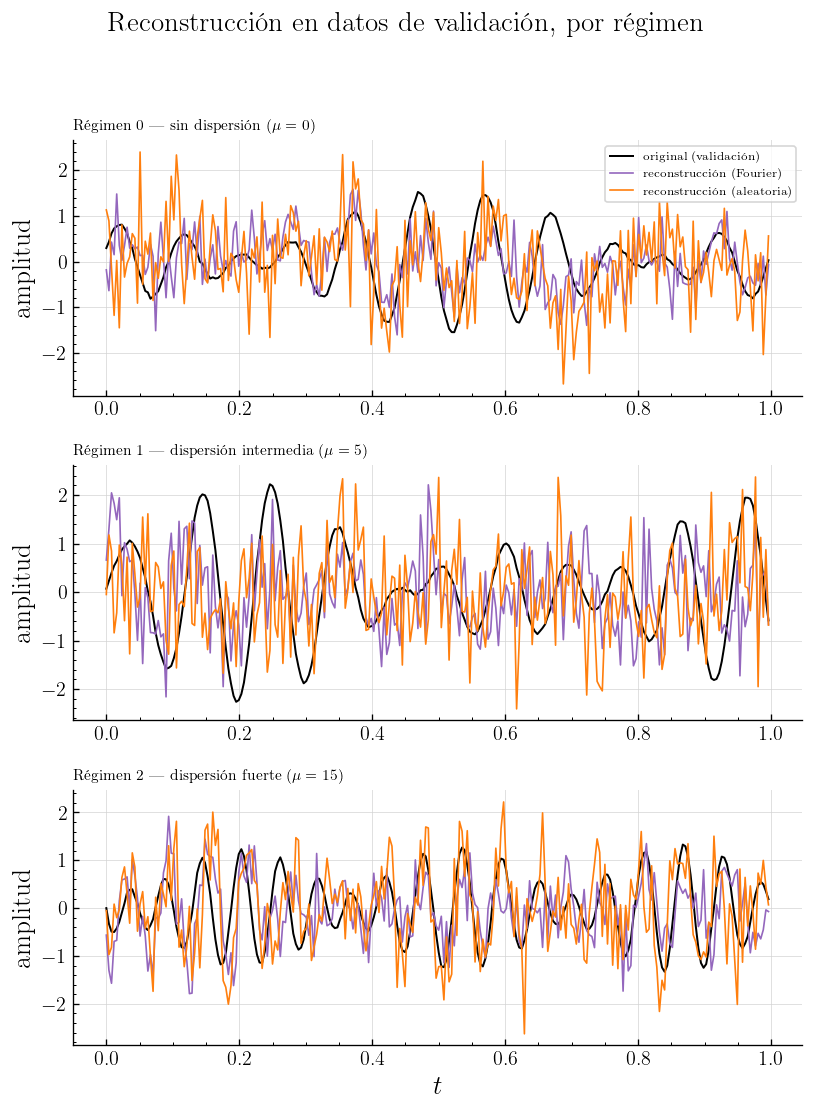

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9))
for r, ax in zip([0, 1, 2], axes):
    res = resultados[r]
    x_val = res["Xval"][0]
    xhat_f = np.array(forward(res["params_f"], jnp.array(x_val)))
    xhat_r = np.array(forward(res["params_r"], jnp.array(x_val)))
    ax.plot(t, x_val, color="k", lw=1.2, label=r"original (validación)")
    ax.plot(t, xhat_f, color=COLOR_INIT["fourier"], lw=1, ls="-", label=r"reconstrucción (Fourier)")
    ax.plot(t, xhat_r, color=COLOR_INIT["aleatoria"], lw=1, ls="-", label=r"reconstrucción (aleatoria)")
    ax.set_title(titulos[r], fontsize=9, loc="left")
    ax.grid(True, color="lightgray", linestyle="-", linewidth=0.6, alpha=0.7, zorder=0)

axes[0].set_ylabel(r"amplitud")
axes[1].set_ylabel(r"amplitud")
axes[2].set_ylabel(r"amplitud")
axes[2].set_xlabel(r"$t$")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle(r"Reconstrucción en datos de validación, por régimen", y=1.03)
fig.tight_layout()
plt.savefig("fig_reconstruccion.pdf")
plt.show()

In [18]:
print(f"{'Régimen':>7} | {'err. rel. train (F)':>20} | {'err. rel. val (F)':>18} | "
      f"{'err. rel. train (R)':>20} | {'err. rel. val (R)':>18}")
for r in [0, 1, 2]:
    res = resultados[r]
    print(f"{r:>7} | {res['err_tr_f']:>20.4f} | {res['err_val_f']:>18.4f} | "
          f"{res['err_tr_r']:>20.4f} | {res['err_val_r']:>18.4f}")


Régimen |  err. rel. train (F) |  err. rel. val (F) |  err. rel. train (R) |  err. rel. val (R)
      0 |               0.4212 |             1.0563 |               0.3692 |             1.3544
      1 |               0.4486 |             1.1642 |               0.3626 |             1.3511
      2 |               0.4234 |             0.8301 |               0.3333 |             1.0058


**Lectura de la tabla.** En entrenamiento, la inicialización aleatoria alcanza menor error en los tres regímenes
(0.33–0.37, frente a 0.42–0.45 con Fourier). Sin embargo, en validación el patrón se invierte: la inicialización
Fourier generaliza mejor en los tres regímenes (0.83–1.16, frente a 1.01–1.35 con aleatoria).

Esto es evidencia de sobreajuste: con solo 12 señales de entrenamiento por régimen y ~25,600 parámetros en la red,
ambas inicializaciones sobreajustan severamente (el error de validación supera 1.0 en varios casos, peor que no
reconstruir nada). La inicialización aleatoria ajusta mejor las señales de entrenamiento, pero esa ganancia no se
traslada a datos nuevos. La inicialización Fourier, al partir de una base con significado físico en vez de pesos
arbitrarios, produce soluciones que generalizan mejor a pesar de ajustar peor los datos vistos durante el
entrenamiento.

**Conclusión de esta sección:** el error que importa para juzgar la red es el de validación, no el de entrenamiento
— y bajo ese criterio, arrancar en la base de Fourier sí ayuda, aunque no se note (o incluso se invierta) si solo se
mira el error de entrenamiento.